# Is your golden set still a sample of your traffic?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/golden-set-builder/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/golden-set-builder/demo.ipynb)

A team labels 240 production conversations once, calls it the golden set, and reports the model's pass
rate on it for a year. This notebook measures how that number drifts away from production, how much of
the drift a free fix removes, which part only new labels remove, and whether the set can see a
regression confined to one small intent. The traffic is synthetic, with its structure declared in the
engine, so every claim can be checked against a known truth.

1. The traffic, and calibration of the exact moments
2. Four ways to allocate 240 cases, scored at month 0 and month 12
3. Staleness, split into mix drift and coverage gap
4. Negative result: a bigger frozen set does not help
5. The refresh: 40 labels, not 240
6. Catching a regression that halves one intent
7. Try your own

## The engine

Extracted from `golden.py` at build time, character for character. Where a design fixes the per-intent
counts n_k, the golden-set pass rate is a weighted sum of independent binomials, so its bias and SD are
exact. Simple random sampling (random counts) with reweighting, and regression power, are Monte Carlo.

In [1]:
from __future__ import annotations

from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA = 0.05


M = 240  # labelling budget: cases in the golden set


MONTHS = 12


INTENTS = ["billing", "password reset", "order status", "refund", "shipping", "account update",
           "product question", "cancel", "bulk export", "API errors", "voice agent", "invoice split"]


EXISTING = 10  # the last two intents launch after month 0: zero traffic when the set is built


_Z = 1 / np.arange(1, EXISTING + 1) ** 1.1


W0 = np.r_[_Z / _Z.sum(), 0.0, 0.0]


NEW_SHARE = np.array([0.08, 0.05])  # traffic share of the two new intents at month 12


W12 = np.r_[W0[:EXISTING] * (1 - NEW_SHARE.sum()) * np.linspace(0.8, 1.6, EXISTING)
            / np.sum(W0[:EXISTING] * np.linspace(0.8, 1.6, EXISTING)), NEW_SHARE]


Q = np.array([0.94, 0.92, 0.95, 0.83, 0.90, 0.88, 0.78, 0.86, 0.72, 0.70, 0.55, 0.60])


DESIGNS = ("random", "proportional", "sqrt", "equal")


FLAKY = 0.08  # share of cases whose outcome is a coin flip on every run (the rest are deterministic)


REG_INTENT = 8  # "bulk export": 2.9% of month-0 traffic


REG_FLIP = 0.5  # v2 breaks half the cases v1 passed there: 0.72 -> 0.36


MC_REPS = 20000


def mix(t: float) -> np.ndarray:
    """Traffic mix at month t: linear from W0 to W12."""
    f = min(max(t / MONTHS, 0.0), 1.0)
    return (1 - f) * W0 + f * W12


def truth(t: float, q: np.ndarray = Q) -> float:
    return float(mix(t) @ q)


def allocate(design: str, m: int = M, w: np.ndarray = W0) -> np.ndarray:
    """Per-intent case counts for a fixed-allocation design (largest remainder, every known intent >= 1)."""
    known = w > 0
    if design == "proportional":
        target = w
    elif design == "sqrt":
        target = np.sqrt(w)
    elif design == "equal":
        target = known.astype(float)
    else:
        raise ValueError(f"{design!r} has no fixed allocation")
    target = target / target.sum() * m
    n = np.floor(target).astype(int)
    n[known & (n == 0)] = 1
    rem = m - n.sum()
    order = np.argsort(-(target - np.floor(target)))
    for i in order:
        if rem == 0:
            break
        if known[i]:
            n[i] += int(np.sign(rem))
            rem -= int(np.sign(rem))
    assert n.sum() == m and np.all(n[~known] == 0)
    return n


def moments(n: np.ndarray, t: float, reweight: bool, q: np.ndarray = Q) -> Dict[str, float]:
    """Exact bias, SD and RMSE of the headline for fixed counts n, against the truth at month t.

    raw:       sum_k (n_k / m) phat_k            (what a dashboard over the golden set shows)
    reweight:  sum_{k covered} v_k phat_k,  v = today's mix renormalised over the intents the set covers
    """
    m = n.sum()
    cov = n > 0
    wt = n / m if not reweight else np.where(cov, mix(t), 0) / np.where(cov, mix(t), 0).sum()
    mean = float(wt @ q)
    var = float(np.sum(np.where(cov, wt ** 2 * q * (1 - q) / np.maximum(n, 1), 0)))
    bias = mean - truth(t, q)
    return {"bias": bias, "sd": float(np.sqrt(var)), "rmse": float(np.sqrt(bias ** 2 + var))}


def moments_random(t: float, reweight: bool, m: int = M, reps: int = MC_REPS, seed: int = 5,
                   q: np.ndarray = Q) -> Dict[str, float]:
    """Simple random sampling from month-0 traffic. Raw is exact (a binomial); reweighted is Monte Carlo."""
    if not reweight:
        p0 = float(W0 @ q)
        bias = p0 - truth(t, q)
        var = p0 * (1 - p0) / m
        return {"bias": bias, "sd": float(np.sqrt(var)), "rmse": float(np.sqrt(bias ** 2 + var)), "exact": True}
    rng = np.random.default_rng(seed)
    n = rng.multinomial(m, W0, size=reps)
    k = rng.binomial(n, q)
    cov = n > 0
    v = np.where(cov, mix(t), 0)
    v = v / v.sum(axis=1, keepdims=True)
    est = np.sum(v * np.where(cov, k / np.maximum(n, 1), 0), axis=1)
    err = est - truth(t, q)
    return {"bias": float(err.mean()), "sd": float(est.std()), "rmse": float(np.sqrt(np.mean(err ** 2))), "exact": False}


def headline(design: str, t: float, reweight: bool, m: int = M) -> Dict[str, float]:
    if design == "random":
        return moments_random(t, reweight, m)
    return {**moments(allocate(design, m), t, reweight), "exact": True}


def coverage_gap(t: float) -> Dict[str, float]:
    """What reweighting cannot fix: the traffic share with no cases, and the bias it leaves."""
    cov = W0 > 0
    w = mix(t)
    v = np.where(cov, w, 0) / w[cov].sum()
    return {"uncovered_share": float(w[~cov].sum()), "bias_left": float(v @ Q - truth(t))}


def refresh(n: np.ndarray, add_per_new: int) -> np.ndarray:
    out = n.copy()
    out[W0 == 0] += add_per_new
    return out


def mcnemar_p(b: np.ndarray, c: np.ndarray) -> np.ndarray:
    """One-sided exact McNemar: P(Binomial(b + c, 1/2) >= b). b = pass->fail, c = fail->pass."""
    return stats.binom.sf(np.asarray(b) - 1, np.asarray(b) + np.asarray(c), 0.5)


def regression_power(n: np.ndarray, flip: float = REG_FLIP, flaky: float = FLAKY, reps: int = MC_REPS,
                     seed: int = 9) -> Dict[str, float]:
    """P(flag) for v1 vs v2 on the same golden cases. With flip = 0 this is the false-alarm rate.

    Each case is flaky with probability `flaky` (passes each run w.p. 1/2) or stable (passes every run w.p.
    s_k, chosen so the marginal pass rate is exactly q_k). In the regressed intent v2 additionally breaks
    a case v1 passed with probability `flip`. Aggregate: one McNemar on all m cases at ALPHA. Per-intent:
    McNemar in each covered intent at ALPHA / (number covered), flag if any fires.
    """
    rng = np.random.default_rng(seed)
    cov = np.flatnonzero(n > 0)
    B = np.zeros((reps, len(Q)), dtype=int)
    C = np.zeros_like(B)
    for k in cov:
        shape = (reps, n[k])
        is_flaky = rng.random(shape) < flaky
        stable_pass = rng.random(shape) < (Q[k] - flaky / 2) / (1 - flaky)
        v1 = np.where(is_flaky, rng.random(shape) < 0.5, stable_pass)
        v2 = np.where(is_flaky, rng.random(shape) < 0.5, stable_pass)
        if k == REG_INTENT and flip > 0:
            v2 &= ~(v1 & (rng.random(shape) < flip))
        B[:, k] = np.sum(v1 & ~v2, axis=1)
        C[:, k] = np.sum(~v1 & v2, axis=1)
    agg = mcnemar_p(B.sum(axis=1), C.sum(axis=1)) < ALPHA
    per = (mcnemar_p(B[:, cov], C[:, cov]) < ALPHA / len(cov)).any(axis=1)
    return {"aggregate": float(agg.mean()), "per_intent": float(per.mean()), "cases_in_regressed": int(n[REG_INTENT])}


def audit(rows: Sequence[Dict], min_share: float = 0.02) -> Dict:
    """The app's core: a golden set's per-intent (cases, passes) against today's traffic counts."""
    names = [str(r["intent"]) for r in rows]
    if len(set(names)) != len(names):
        raise ValueError("each intent must appear once")
    n = np.array([int(r["cases"]) for r in rows])
    k = np.array([int(r["passes"]) for r in rows])
    traffic = np.array([float(r["traffic"]) for r in rows])
    if np.any(n < 0) or np.any(k < 0) or np.any(k > n) or np.any(traffic < 0):
        raise ValueError("need 0 <= passes <= cases and traffic >= 0")
    if n.sum() == 0 or traffic.sum() == 0:
        raise ValueError("need at least one labelled case and some traffic")
    w = traffic / traffic.sum()
    cov = n > 0
    raw = float(k.sum() / n.sum())
    v = np.where(cov, w, 0)
    rew = float(np.sum(v / v.sum() * np.where(cov, k / np.maximum(n, 1), 0)))
    rows_out = []
    for i, name in enumerate(names):
        lo, hi = wilson(int(k[i]), int(n[i])) if n[i] else (float("nan"), float("nan"))
        rows_out.append({"intent": name, "traffic share": float(w[i]), "set share": float(n[i] / n.sum()),
                         "cases": int(n[i]), "pass rate": float(k[i] / n[i]) if n[i] else float("nan"),
                         "99% low": lo, "99% high": hi})
    gaps = [names[i] for i in range(len(names)) if not cov[i] and w[i] >= min_share]
    return {"raw": raw, "reweighted": rew, "uncovered_share": float(w[~cov].sum()), "gaps": gaps,
            "thin": [names[i] for i in range(len(names)) if cov[i] and n[i] < 10 and w[i] >= min_share],
            "rows": rows_out}


def wilson(k: int, n: int, z: float = float(stats.norm.isf(0.005))) -> List[float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [float(mid - half), float(mid + half)]


def calibrate(reps: int = MC_REPS, seed: int = 21) -> Dict:
    """The exact moments against a raw simulation of drawing and labelling the set."""
    rng = np.random.default_rng(seed)
    out = []
    for design in ("proportional", "equal"):
        n = allocate(design)
        for t, rw in ((0, False), (12, False), (12, True)):
            k = rng.binomial(n, Q, size=(reps, len(Q)))
            cov = n > 0
            wt = n / n.sum() if not rw else np.where(cov, mix(t), 0) / np.where(cov, mix(t), 0).sum()
            est = np.sum(wt * np.where(cov, k / np.maximum(n, 1), 0), axis=1)
            ex = moments(n, t, rw)
            se_mean = est.std() / np.sqrt(reps)
            out.append({"design": design, "month": t, "reweight": rw, "exact_bias": ex["bias"],
                        "mc_bias": float(est.mean() - truth(t)), "exact_sd": ex["sd"], "mc_sd": float(est.std()),
                        "bias_z": float((est.mean() - truth(t) - ex["bias"]) / se_mean),
                        "sd_ratio": float(est.std() / ex["sd"])})
    # the McNemar p-value against scipy's exact binomial test
    mism = sum(abs(float(mcnemar_p(b, c)) - stats.binomtest(b, b + c, 0.5, alternative="greater").pvalue) > 1e-12
               for b in range(0, 15) for c in range(0, 15) if b + c > 0)
    return {"moments": out, "mcnemar_vs_binomtest_mismatches": int(mism), "mcnemar_cases": 224}

print('engine loaded')

engine loaded


**Resolution of the instrument.** The estimation numbers are exact and match `evidence.txt` to the digit.
The regression-power cells run at 4,000 replicates here instead of the study's 20,000, so they can
differ from `evidence.txt` in the second decimal - lower resolution, not disagreement. `evidence.txt` is
the reference.

## 1. The traffic and the calibration

In [2]:
for i, name in enumerate(INTENTS):
    print(f"{name:<17} month 0 {W0[i]:.3f}   month 12 {W12[i]:.3f}   pass rate {Q[i]:.2f}")
print(f"production pass rate: month 0 {truth(0):.4f}, month 12 {truth(12):.4f}")
cal = calibrate(4000)
for r in cal["moments"]:
    print(f"{r['design']:<12} m{r['month']:<2} {'rew' if r['reweight'] else 'raw'}  bias z {r['bias_z']:+.2f}  sd ratio {r['sd_ratio']:.3f}")
print("McNemar vs scipy binomtest mismatches:", cal["mcnemar_vs_binomtest_mismatches"])

billing           month 0 0.373   month 12 0.260   pass rate 0.94
password reset    month 0 0.174   month 12 0.135   pass rate 0.92
order status      month 0 0.111   month 12 0.095   pass rate 0.95
refund            month 0 0.081   month 12 0.076   pass rate 0.83
shipping          month 0 0.064   month 12 0.064   pass rate 0.90
account update    month 0 0.052   month 12 0.056   pass rate 0.88
product question  month 0 0.044   month 12 0.051   pass rate 0.78
cancel            month 0 0.038   month 12 0.047   pass rate 0.86
bulk export       month 0 0.033   month 12 0.044   pass rate 0.72
API errors        month 0 0.030   month 12 0.041   pass rate 0.70
voice agent       month 0 0.000   month 12 0.080   pass rate 0.55
invoice split     month 0 0.000   month 12 0.050   pass rate 0.60
production pass rate: month 0 0.8986, month 12 0.8443
proportional m0  raw  bias z -2.12  sd ratio 0.991
proportional m12 raw  bias z -0.54  sd ratio 0.986
proportional m12 rew  bias z +0.32  sd ratio 0.996
e

## 2. Four allocations of 240 cases

In [3]:
for d in DESIGNS:
    cells = [headline(d, t, rw) for t, rw in ((0, False), (0, True), (12, False), (12, True))]
    print(f"{d:<13}" + "  ".join(f"{100 * c['bias']:+5.1f}+/-{100 * c['sd']:.1f}" for c in cells))
print("columns: month 0 raw, month 0 reweighted, month 12 raw, month 12 reweighted (pts)")

random        +0.0+/-1.9   -0.0+/-2.0   +5.4+/-1.9   +4.1+/-2.3
proportional  +0.0+/-1.9   +0.0+/-1.9   +5.4+/-1.9   +4.1+/-2.2
sqrt          -2.4+/-2.1   +0.0+/-1.9   +3.0+/-2.1   +4.1+/-2.0
equal         -5.1+/-2.3   +0.0+/-2.3   +0.4+/-2.3   +4.1+/-2.2
columns: month 0 raw, month 0 reweighted, month 12 raw, month 12 reweighted (pts)


Proportional (and random) allocation is right at month 0 and 5.4 points high by month 12. Equal
allocation is 5.1 points LOW at month 0 if you report its raw pass rate, because it over-samples the
hard tail intents; reweighted it is unbiased, at an RMSE of 2.34 instead of 1.90. At month 12 its raw
number happens to land near the truth (+0.4): two errors cancelling, not a property worth relying on.
Reweighted, every design ends at exactly the same +4.1 - the part no design fixes.

## 3. Staleness, decomposed

month  0: raw +0.0  reweighted +0.0  uncovered traffic 0.0%
month  2: raw +0.9  reweighted +0.7  uncovered traffic 2.2%
month  4: raw +1.8  reweighted +1.4  uncovered traffic 4.3%
month  6: raw +2.7  reweighted +2.1  uncovered traffic 6.5%
month  8: raw +3.6  reweighted +2.8  uncovered traffic 8.7%
month 10: raw +4.5  reweighted +3.5  uncovered traffic 10.8%
month 12: raw +5.4  reweighted +4.1  uncovered traffic 13.0%


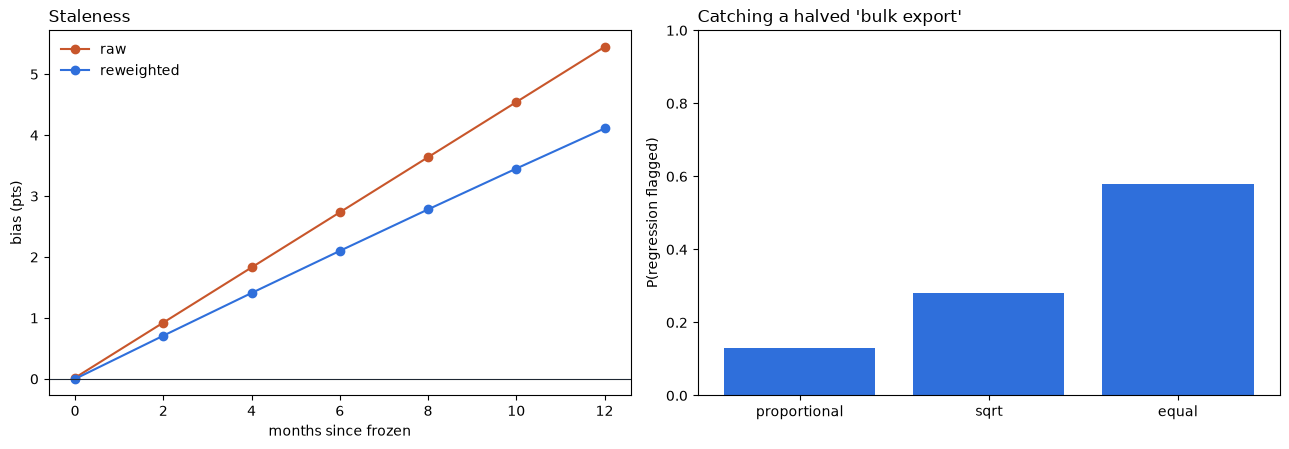

In [4]:
n = allocate("proportional")
months = list(range(0, 13, 2))
raw = [100 * moments(n, t, False)["bias"] for t in months]
rew = [100 * moments(n, t, True)["bias"] for t in months]
gap = [coverage_gap(t)["uncovered_share"] for t in months]
for t, a, b, g in zip(months, raw, rew, gap):
    print(f"month {t:>2}: raw {a:+.1f}  reweighted {b:+.1f}  uncovered traffic {g:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(months, raw, "o-", color="#c8562b", label="raw")
axes[0].plot(months, rew, "o-", color="#2f6fdb", label="reweighted")
axes[0].axhline(0, color="#1f2733", lw=0.8)
axes[0].set_xlabel("months since frozen"); axes[0].set_ylabel("bias (pts)"); axes[0].legend(frameon=False)
axes[0].set_title("Staleness", loc="left")
designs = ["proportional", "sqrt", "equal"]
pw = [regression_power(allocate(d), reps=4000)["aggregate"] for d in designs]
axes[1].bar(designs, pw, color="#2f6fdb")
axes[1].set_ylim(0, 1); axes[1].set_ylabel("P(regression flagged)")
axes[1].set_title("Catching a halved 'bulk export'", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

Reweighting per-intent pass rates by this month's traffic counts - which need no labels - removes the
1.3 points caused by the mix shifting between intents that already existed. The other 4.1 points come
from the 13% of traffic in two intents launched after the set was built. They have no cases, so no
weighting scheme can see them.

## 4. Negative result - a bigger frozen set

In [5]:
for m in (60, 240, 960, 2400):
    a, b = headline("proportional", 12, False, m), headline("proportional", 12, True, m)
    print(f"m = {m:>5}: raw {100 * a['bias']:+.1f} (SD {100 * a['sd']:.2f})   reweighted {100 * b['bias']:+.1f} (SD {100 * b['sd']:.2f})")

m =    60: raw +5.3 (SD 3.83)   reweighted +4.1 (SD 4.29)
m =   240: raw +5.4 (SD 1.90)   reweighted +4.1 (SD 2.17)
m =   960: raw +5.4 (SD 0.95)   reweighted +4.1 (SD 1.08)
m =  2400: raw +5.4 (SD 0.60)   reweighted +4.1 (SD 0.68)


Ten times the labels shrinks the SD and leaves the bias where it was: a more precise wrong number. The
instinct "our eval set is too small" is right about noise and wrong about staleness.

## 5. The refresh

In [6]:
for add in (0, 5, 10, 20, 40):
    nn = refresh(allocate("proportional"), add)
    a, b = moments(nn, 12, False), moments(nn, 12, True)
    print(f"+{add:>2} per new intent: raw bias {100 * a['bias']:+.1f}, reweighted bias {100 * b['bias']:+.1f}, RMSE {100 * b['rmse']:.2f}")

+ 0 per new intent: raw bias +5.4, reweighted bias +4.1, RMSE 4.65
+ 5 per new intent: raw bias +4.2, reweighted bias +0.0, RMSE 2.81
+10 per new intent: raw bias +3.0, reweighted bias +0.0, RMSE 2.40
+20 per new intent: raw bias +0.8, reweighted bias +0.0, RMSE 2.16
+40 per new intent: raw bias -2.6, reweighted bias +0.0, RMSE 2.03


Five labels per new intent remove the bias entirely (once reweighted); 20 each - 40 labels, a sixth of a
rebuild - bring the RMSE back to 2.16 against 1.90 at month 0. Without the reweighting the raw number
overshoots as soon as the new intents are over-represented, so the two fixes go together.

## 6. Catching a regression confined to one intent

In [7]:
for d in ("proportional", "sqrt", "equal"):
    nn = allocate(d)
    p, f = regression_power(nn, reps=4000), regression_power(nn, flip=0, reps=4000)
    print(f"{d:<13} {p['cases_in_regressed']:>2} cases there   aggregate {p['aggregate']:.3f}   per-intent {p['per_intent']:.3f}"
          f"   false alarms {f['aggregate']:.3f} / {f['per_intent']:.3f}")

proportional   8 cases there   aggregate 0.130   per-intent 0.001   false alarms 0.024 / 0.000
sqrt          15 cases there   aggregate 0.281   per-intent 0.127   false alarms 0.021 / 0.000
equal         24 cases there   aggregate 0.580   per-intent 0.509   false alarms 0.019 / 0.000


v2 breaks half of the passing cases in "bulk export" (0.72 -> 0.36), a 1.6-point drop in production.
The proportional set holds 8 such cases and flags it about 12% of the time. The equal set holds 24 and
flags it 57%. Per-intent alerting with a Bonferroni correction does NOT help here - the correction costs
more than the slicing buys - so slice to diagnose, not to detect.

The first version of this simulation flipped every outcome with probability 0.03 between runs. That
lowers a re-run's pass rate (there are nine passes to flip for every fail), and the aggregate test
flagged the SAME model 58% of the time. Flakiness is now modelled per case, and a test pins the false-
alarm rate under 0.06.

## Summary

| claim | what the numbers say |
|---|---|
| "our golden set tracks production" | frozen for 12 months: 89.9% on the set, 84.4% in production |
| "reweight it and it is fine" | removes 1.3 of 5.4 pts; 4.1 is traffic with no cases |
| "we need a bigger set" | 10x the labels, same +4.1 bias |
| "the headline set also catches regressions" | proportional: 12% chance on a halved 3% intent; equal + reweighting: 57%, unbiased headline |

## 7. Try your own

In [8]:
# rows = [
#     {"intent": "billing", "cases": 90, "passes": 85, "traffic": 26000},
#     {"intent": "refund", "cases": 19, "passes": 16, "traffic": 7600},
#     {"intent": "voice agent", "cases": 0, "passes": 0, "traffic": 8000},
# ]
# a = audit(rows)
# print(f"raw {a['raw']:.3f}  reweighted {a['reweighted']:.3f}  uncovered {a['uncovered_share']:.1%}  gaps {a['gaps']}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/golden-set-builder)

Streamlit version, where you paste your own golden set against this period's traffic:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`rag-eval`](../rag-eval) and [`../../ai-agent-workshop/agent-eval-dashboard`](../../ai-agent-workshop/agent-eval-dashboard)
run a fixed suite; this one asks whether the suite still represents traffic.
[`../../data-science-cookbook/proportion-test`](../../data-science-cookbook/proportion-test) shows why the test
you pick on a 2x2 changes the answer.